# Etna Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Etna dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend; only lagged `tau >= 1` parents are fed into the Cause–Trigger F-test, while contemporaneous `tau = 0` links are stored as diagnostics.

## 1. Imports and paths
This section loads the local modules from `src/` and sets data paths.  

In [1]:
from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data/etna"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from cause_trigger import (
    CauseTriggerConfig,
    run_cause_trigger,
    find_increase_split,
    diagnostics_to_dataframe,
)

from parameter_extraction import find_parameters

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)

## 2. Load and prepare Etna dataset

The Cause–Trigger module expects a fully numeric, standardized/scaled dataframe with a time index and no missing values.  

In [6]:
etna_path = DATA_DIR / "etna_final.csv"
etna = pd.read_csv(etna_path, parse_dates=["time"])

X_all = (
    etna
    .drop(columns=["station"], errors="ignore")
    .set_index("time")
    .sort_index()
)

X_all = X_all.select_dtypes(include=[np.number])

print("Model dataframe shape:", X_all.shape)
print("Start:", X_all.index.min())
print("End:", X_all.index.max())
display(X_all.head())
display(X_all.isna().sum())

if X_all.isna().any().any():
    raise ValueError("X_all contains NaNs. Fix before running Cause–Trigger.")

Model dataframe shape: (768, 9)
Start: 2008-04-12 00:00:00+00:00
End: 2008-05-13 23:00:00+00:00


,teleseismic_scaled,background_seismic_scaled,effect_seismic_scaled,CO2_3_scaled,AirTemp_3_scaled,pressure_drop_scaled,WindSpeed_scaled,API_scaled,CO2_SO2_scaled
time,,,,,,,,,
2008-04-12 00:00:00+00:00,39.110016,-0.263282,-0.519972,-1.484749,0.360327,-0.248498,-0.674491,-0.676991,1.085595
2008-04-12 01:00:00+00:00,14.873179,-0.197218,-0.059683,-1.877788,1.681098,0.212995,-0.357083,-0.676991,1.085595
2008-04-12 02:00:00+00:00,30.266895,-0.328373,-0.618714,-1.509194,0.718089,0.709988,-0.674491,-0.676991,1.085595
2008-04-12 03:00:00+00:00,1.704858,-0.222941,-0.627508,-1.680912,0.811697,0.425993,-0.674491,-0.676991,1.085595
2008-04-12 04:00:00+00:00,40.146476,-0.428496,-0.323165,-1.705446,0.578318,-0.141998,-0.674491,-0.676991,1.085595


teleseismic_scaled           0
background_seismic_scaled    0
effect_seismic_scaled        0
CO2_3_scaled                 0
AirTemp_3_scaled             0
pressure_drop_scaled         0
WindSpeed_scaled             0
API_scaled                   0
CO2_SO2_scaled               0
dtype: int64

## 3. Analysis configuration

For the first controlled comparison, all three backends use the same:

- effect variable,
- lag length,
- alpha,
- split-length constraints,
- Gaussian distribution,
- `beta_is_ones=False` for baseline behavior.

For Etna, `effect_seismic_scaled` is treated as the effect/response variable.  

In [7]:
EFFECT = "effect_seismic_scaled"
ETNA_EVENT_TIME = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

ALPHA = 0.05
MANUAL_LAG = 3
MAX_LAGS = 6

MIN_I1_LENGTH = 48
MIN_I2_LENGTH = 48

SELECTED_DISTRIBUTION = "gaussian"

# baseline / thesis-extension weighting logic
HMML_V_WEIGHTING = "backend"      # HMML provides beta_star directly
PCMCI_V_WEIGHTING = "refit"       # PCMCI/PCMCI+ need beta_star refit

# Refit methods used for PCMCI/PCMCI+ extensions
REFIT_METHODS = ("ridge", "adaptive_lasso")

REFIT_CV = True
REFIT_CV_FOLDS = 5
REFIT_ALPHA = 1.0
REFIT_LASSO_MAX_ITER = 50000
ADAPTIVE_GAMMA = 1.0
ADAPTIVE_EPSILON = 1e-6

X_FULL = X_all.copy()
df_model = X_FULL.copy()

print("Effect variable:", EFFECT)
print("Manual lag:", MANUAL_LAG)
print("Distribution:", SELECTED_DISTRIBUTION)
print("Known event time:", ETNA_EVENT_TIME)
print("Dataset:", X_FULL.index.min(), "to", X_FULL.index.max())
print("Shape:", X_FULL.shape)

Effect variable: effect_seismic_scaled
Manual lag: 3
Distribution: gaussian
Known event time: 2008-05-12 06:28:00+00:00
Dataset: 2008-04-12 00:00:00+00:00 to 2008-05-13 23:00:00+00:00
Shape: (768, 9)


## 4. Split diagnostics before running causal discovery

This checks whether the split condition behaves sensibly for the chosen effect.  
The split is selected by maximizing:

`|E(effect)|_I2 - |E(effect)|_I1`

subject to the minimum interval lengths.

In [8]:
def split_diagnostics(
    X,
    effect,
    event_time=None,
    min_I1_length=48,
    min_I2_length=48,
):
    split_idx = find_increase_split(
        X[effect],
        min_I1_length=min_I1_length,
        min_I2_length=min_I2_length,
    )

    if split_idx is None:
        return {
            "effect": effect,
            "split_index": None,
            "split_time": None,
            "I1_length": None,
            "I2_length": None,
            "abs_mean_I1": None,
            "abs_mean_I2": None,
            "abs_mean_difference": None,
            "distance_to_event": None,
        }

    I1 = X.iloc[:split_idx]
    I2 = X.iloc[split_idx:]
    split_time = X.index[split_idx]

    out = {
        "effect": effect,
        "split_index": split_idx,
        "split_time": split_time,
        "I1_length": len(I1),
        "I2_length": len(I2),
        "abs_mean_I1": abs(I1[effect].mean()),
        "abs_mean_I2": abs(I2[effect].mean()),
        "abs_mean_difference": abs(I2[effect].mean()) - abs(I1[effect].mean()),
        "distance_to_event": None,
    }

    if event_time is not None:
        out["distance_to_event"] = split_time - event_time

    return out


split_table = pd.DataFrame([
    split_diagnostics(
        X_FULL,
        effect=EFFECT,
        event_time=ETNA_EVENT_TIME,
        min_I1_length=MIN_I1_LENGTH,
        min_I2_length=MIN_I2_LENGTH,
    )
])

display(split_table)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,distance_to_event
0,effect_seismic_scaled,661,2008-05-09 13:00:00+00:00,661,107,59068.985054,95759.024179,36690.039126,-3 days +06:32:00


## 5. Shared result helpers

These functions keep the backend sections tidy and ensure every run is summarized in the same way.

In [9]:
def summarize_result(result, title=None):
    if title:
        print("\n" + "=" * 100)
        print(title)
        print("=" * 100)

    print("Backend:", result.get("backend"))
    print("Configured lags:", result.get("configured_lags"))
    print("Configured distribution:", result.get("configured_distribution"))
    print("Parameter source:", result.get("parameter_source"))
    print("V weighting:", result.get("v_weighting"))
    print("Refit method:", result.get("refit_method"))
    if result.get("refit_metadata"):
        print("Refit metadata:")
        display(result["refit_metadata"])
    print("Split index:", result.get("split_index"))
    print("Split timestamp:", result.get("split_timestamp"))
    print("I1 length:", result.get("I1_length"))
    print("I2 length:", result.get("I2_length"))
    print("Effect abs mean difference:", result.get("target_abs_mean_difference"))
    print("B1:", result.get("B_1"))
    print("B2:", result.get("B_2"))
    print("Autoregressive effect parent in B2:", result.get("autoregressive_parent_in_B2"))
    print("Trigger candidates:", result.get("T_candidates"))
    print("Accepted triggers:", result.get("T"))
    print("Causes:", result.get("C"))
    print("Cause-trigger pairs:", result.get("pairs"))

    scores = result.get("causal_scores", {})

    if "_hmml_metadata" in scores:
        print("HMML metadata:")
        display(scores["_hmml_metadata"])

    if "_pcmci_metadata" in scores:
        print("PCMCI/PCMCI+ metadata:")
        display(scores["_pcmci_metadata"])

    contemp = result.get("contemporaneous_links", {})
    if contemp:
        print("PCMCI+ contemporaneous tau=0 links to effect, stored as diagnostics only:")
        display(pd.DataFrame.from_dict(contemp, orient="index"))

    if result.get("selected_cause_shift_scores"):
        print("Cause-selection shift scores by trigger:")
        display(result["selected_cause_shift_scores"])

    diag = diagnostics_to_dataframe(result)

    if len(diag) > 0:
        sort_cols = [c for c in ["accepted", "p_value", "rss_reduction_ratio"] if c in diag.columns]
        if sort_cols:
            ascending = []
            for c in sort_cols:
                ascending.append(False if c in ["accepted", "rss_reduction_ratio"] else True)
            diag = diag.sort_values(sort_cols, ascending=ascending)

        display(diag)

    return diag


def compact_result_row(name, effect, result):
    return {
        "run": name,
        "effect": effect,
        "backend": result.get("backend"),
        "parameter_source": result.get("parameter_source"),
        "configured_lags": result.get("configured_lags"),
        "configured_distribution": result.get("configured_distribution"),
        "v_weighting": result.get("v_weighting"),
        "refit_method": result.get("refit_method"),
        "refit_nonzero_beta_count": (
            result.get("refit_metadata", {}).get("nonzero_beta_count")
            if result.get("refit_metadata") else None
        ),
        "refit_alpha_used": (
            result.get("refit_metadata", {}).get("refit_alpha_used")
            if result.get("refit_metadata") else None
        ),
        "split_index": result.get("split_index"),
        "split_timestamp": result.get("split_timestamp"),
        "I1_length": result.get("I1_length"),
        "I2_length": result.get("I2_length"),
        "B1": result.get("B_1"),
        "B2": result.get("B_2"),
        "autoregressive_effect_parent_in_B2": result.get("autoregressive_parent_in_B2"),
        "trigger_candidates": result.get("T_candidates"),
        "accepted_triggers": result.get("T"),
        "causes": result.get("C"),
        "pairs": result.get("pairs"),
        "n_contemporaneous_links": len(result.get("contemporaneous_links", {}) or {}),
    }


def add_run_label(diag, run_name, effect, backend, parameter_source, v_weighting=None, refit_method=None):
    if diag is None or len(diag) == 0:
        return pd.DataFrame()

    out = diag.copy()
    out["run"] = run_name
    out["effect"] = effect
    out["backend"] = backend
    out["parameter_source"] = parameter_source
    out["v_weighting"] = v_weighting
    out["refit_method"] = refit_method
    return out


def plot_effect_with_split(df, effect, result, event_time=None, title_suffix=""):
    plt.figure(figsize=(16, 4))
    plt.plot(df.index, df[effect], label=effect, linewidth=0.8)

    split_timestamp = result.get("split_timestamp")
    if split_timestamp is not None:
        plt.axvline(split_timestamp, linestyle="--", label="Detected split")

    if event_time is not None:
        event_time = pd.Timestamp(event_time)
        plt.axvline(event_time, linestyle=":", label="Known event time")

    plt.title(f"Effect {effect}: detected split vs known event {title_suffix}")
    plt.xlabel("Time")
    plt.ylabel("Scaled value")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Shared backend runner

This function creates a `CauseTriggerConfig`, runs the algorithm, and returns the result and diagnostics.  
The backend-specific settings are controlled through `causal_backend`.

In [10]:
def default_weighting_for_backend(backend, refit_method=None):
    """
    - HMML is the baseline: beta_star from HMML.
    - PCMCI/PCMCI+ are thesis extensions: beta_star must be refit.
    """
    if backend == "hmml":
        return "backend", None

    if backend in {"pcmci", "pcmci_plus"}:
        if refit_method is None:
            refit_method = "ridge"
        return "refit", refit_method

    raise ValueError(f"Unknown backend: {backend}")


def make_config(
    backend,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
    parameter_source=None,
    cond_ind_test="parcorr",
    refit_method=None,
):
    v_weighting, resolved_refit_method = default_weighting_for_backend(
        backend=backend,
        refit_method=refit_method,
    )

    if parameter_source is None:
        if backend == "hmml":
            parameter_source = f"{backend}_manual_lag{lag}_{distribution}_backend_beta"
        else:
            parameter_source = (
                f"{backend}_manual_lag{lag}_{distribution}_"
                f"{resolved_refit_method}_refit"
            )

    return CauseTriggerConfig(
        y_t=effect,
        lags=lag,
        distribution=distribution,
        causal_backend=backend,
        alpha=ALPHA,
        min_I1_length=MIN_I1_LENGTH,
        min_I2_length=MIN_I2_LENGTH,
        parameter_source=parameter_source,

        # V weighting / beta_star logic
        v_weighting=v_weighting,
        refit_method=resolved_refit_method or "ridge",
        refit_alpha=REFIT_ALPHA,
        refit_cv=REFIT_CV,
        refit_cv_folds=REFIT_CV_FOLDS,
        refit_lasso_max_iter=REFIT_LASSO_MAX_ITER,
        adaptive_gamma=ADAPTIVE_GAMMA,
        adaptive_epsilon=ADAPTIVE_EPSILON,

        # PCMCI / PCMCI+ settings
        pcmci_pc_alpha=0.05,
        pcmci_alpha_level=0.05,
        pcmci_fdr_method="fdr_bh",
        pcmci_cond_ind_test=cond_ind_test,
        pcmci_verbosity=0,

        # PCMCI+ settings
        pcmci_contemp_collider_rule="majority",
        pcmci_conflict_resolution=True,
        pcmci_keep_raw_results=False,
    )


def run_backend(
    backend,
    X=X_FULL,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
    cond_ind_test="parcorr",
    refit_method=None,
):
    config = make_config(
        backend=backend,
        effect=effect,
        lag=lag,
        distribution=distribution,
        parameter_source=None,
        cond_ind_test=cond_ind_test,
        refit_method=refit_method,
    )

    result = run_cause_trigger(X, config)

    if backend == "hmml":
        title = "HMML"
    else:
        title = f"{backend.upper()} — {config.refit_method} refit"

    diag = summarize_result(result, title=title)
    return result, diag

## 7. Run Backends + compare

- HMML
- PCMCI lagged causal-discovery sensitivity
- PCMCI+ causal-discovery sensitivity

PCMCI is used here only for lagged parent discovery.  

PCMCI+ can identify both lagged and contemporaneous links.  
For the Cause–Trigger algorithm, only lagged `tau >= 1` links are used in `B2`.  
Contemporaneous `tau = 0` links are stored separately in `result['contemporaneous_links']`.

The table compares the key algorithm outputs across HMML, PCMCI, and PCMCI+.

In [11]:
result_hmml, diag_hmml = run_backend(
    backend="hmml",
    X=X_FULL,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom



HMML
Backend: hmml
Configured lags: 3
Configured distribution: gaussian
Parameter source: hmml_manual_lag3_gaussian_backend_beta
V weighting: backend
Refit method: None
Refit metadata:


{'v_weighting': 'backend', 'source': 'hmml'}

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: ['background_seismic_scaled']
B2: ['CO2_3_scaled']
Autoregressive effect parent in B2: False
Trigger candidates: ['CO2_3_scaled']
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
HMML metadata:


{'requested_distribution': 'gaussian',
 'used_distribution': 'gaussian',
 'used_fallback': False}

In [12]:
result_pcmci_ridge, diag_pcmci_ridge = run_backend(
    backend="pcmci",
    X=X_FULL,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
    cond_ind_test="parcorr",
    refit_method="ridge",
)


PCMCI — ridge refit
Backend: pcmci
Configured lags: 3
Configured distribution: gaussian
Parameter source: pcmci_manual_lag3_gaussian_ridge_refit
V weighting: refit
Refit method: ridge
Refit metadata:


{'refit_method': 'ridge',
 'reason': 'no selected parents',
 'nonzero_beta_count': 0}

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: ['background_seismic_scaled']
B2: []
Autoregressive effect parent in B2: False
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
PCMCI/PCMCI+ metadata:


{'method': 'pcmci',
 'tau_max': 3,
 'pc_alpha': 0.05,
 'alpha_level': 0.05,
 'fdr_method': 'fdr_bh',
 'cond_ind_test': 'parcorr',
 'contemp_collider_rule': 'majority',
 'conflict_resolution': True}

In [13]:
result_pcmci_adaptive, diag_pcmci_adaptive = run_backend(
    backend="pcmci",
    X=X_FULL,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
    cond_ind_test="parcorr",
    refit_method="adaptive_lasso",
)


PCMCI — adaptive_lasso refit
Backend: pcmci
Configured lags: 3
Configured distribution: gaussian
Parameter source: pcmci_manual_lag3_gaussian_adaptive_lasso_refit
V weighting: refit
Refit method: adaptive_lasso
Refit metadata:


{'refit_method': 'adaptive_lasso',
 'reason': 'no selected parents',
 'nonzero_beta_count': 0}

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: ['background_seismic_scaled']
B2: []
Autoregressive effect parent in B2: False
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
PCMCI/PCMCI+ metadata:


{'method': 'pcmci',
 'tau_max': 3,
 'pc_alpha': 0.05,
 'alpha_level': 0.05,
 'fdr_method': 'fdr_bh',
 'cond_ind_test': 'parcorr',
 'contemp_collider_rule': 'majority',
 'conflict_resolution': True}

In [14]:
result_pcmci_plus_ridge, diag_pcmci_plus_ridge = run_backend(
    backend="pcmci_plus",
    X=X_FULL,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
    cond_ind_test="parcorr",
    refit_method="ridge",
)

print("PCMCI+ Ridge contemporaneous links:")
display(pd.DataFrame.from_dict(result_pcmci_plus_ridge.get("contemporaneous_links", {}), orient="index"))


PCMCI_PLUS — ridge refit
Backend: pcmci_plus
Configured lags: 3
Configured distribution: gaussian
Parameter source: pcmci_plus_manual_lag3_gaussian_ridge_refit
V weighting: refit
Refit method: ridge
Refit metadata:


{'refit_method': 'ridge',
 'reason': 'no selected parents',
 'nonzero_beta_count': 0}

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: []
B2: []
Autoregressive effect parent in B2: False
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
PCMCI/PCMCI+ metadata:


{'method': 'pcmci_plus',
 'tau_max': 3,
 'pc_alpha': 0.05,
 'alpha_level': 0.05,
 'fdr_method': 'fdr_bh',
 'cond_ind_test': 'parcorr',
 'contemp_collider_rule': 'majority',
 'conflict_resolution': True}

PCMCI+ contemporaneous tau=0 links to effect, stored as diagnostics only:


,graph_link,p_value,val
teleseismic_scaled,o-o,4.141430e-34,0.883871
background_seismic_scaled,o-o,5.523163e-05,0.391904


PCMCI+ Ridge contemporaneous links:


,graph_link,p_value,val
teleseismic_scaled,o-o,4.141430e-34,0.883871
background_seismic_scaled,o-o,5.523163e-05,0.391904


In [15]:
result_pcmci_plus_adaptive, diag_pcmci_plus_adaptive = run_backend(
    backend="pcmci_plus",
    X=X_FULL,
    effect=EFFECT,
    lag=MANUAL_LAG,
    distribution=SELECTED_DISTRIBUTION,
    cond_ind_test="parcorr",
    refit_method="adaptive_lasso",
)

print("PCMCI+ Adaptive Lasso contemporaneous links:")
display(pd.DataFrame.from_dict(result_pcmci_plus_adaptive.get("contemporaneous_links", {}), orient="index"))


PCMCI_PLUS — adaptive_lasso refit
Backend: pcmci_plus
Configured lags: 3
Configured distribution: gaussian
Parameter source: pcmci_plus_manual_lag3_gaussian_adaptive_lasso_refit
V weighting: refit
Refit method: adaptive_lasso
Refit metadata:


{'refit_method': 'adaptive_lasso',
 'reason': 'no selected parents',
 'nonzero_beta_count': 0}

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: []
B2: []
Autoregressive effect parent in B2: False
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
PCMCI/PCMCI+ metadata:


{'method': 'pcmci_plus',
 'tau_max': 3,
 'pc_alpha': 0.05,
 'alpha_level': 0.05,
 'fdr_method': 'fdr_bh',
 'cond_ind_test': 'parcorr',
 'contemp_collider_rule': 'majority',
 'conflict_resolution': True}

PCMCI+ contemporaneous tau=0 links to effect, stored as diagnostics only:


,graph_link,p_value,val
teleseismic_scaled,o-o,4.141430e-34,0.883871
background_seismic_scaled,o-o,5.523163e-05,0.391904


PCMCI+ Adaptive Lasso contemporaneous links:


,graph_link,p_value,val
teleseismic_scaled,o-o,4.141430e-34,0.883871
background_seismic_scaled,o-o,5.523163e-05,0.391904


In [16]:
results_by_run = {
    "hmml_backend_beta": result_hmml,
    "pcmci_ridge": result_pcmci_ridge,
    "pcmci_adaptive_lasso": result_pcmci_adaptive,
    "pcmci_plus_ridge": result_pcmci_plus_ridge,
    "pcmci_plus_adaptive_lasso": result_pcmci_plus_adaptive,
}

comparison = pd.DataFrame([
    compact_result_row("hmml_backend_beta", EFFECT, result_hmml),
    compact_result_row("pcmci_ridge", EFFECT, result_pcmci_ridge),
    compact_result_row("pcmci_adaptive_lasso", EFFECT, result_pcmci_adaptive),
    compact_result_row("pcmci_plus_ridge", EFFECT, result_pcmci_plus_ridge),
    compact_result_row("pcmci_plus_adaptive_lasso", EFFECT, result_pcmci_plus_adaptive),
])

display(comparison)

,run,effect,backend,parameter_source,configured_lags,configured_distribution,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,split_index,split_timestamp,I1_length,I2_length,B1,B2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links
0,hmml_backend_beta,effect_seismic_scaled,hmml,hmml_manual_lag3_gaussian_backend_beta,3,gaussian,backend,None,NaN,None,661,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0
1,pcmci_ridge,effect_seismic_scaled,pcmci,pcmci_manual_lag3_gaussian_ridge_refit,3,gaussian,refit,ridge,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0
2,pcmci_adaptive_lasso,effect_seismic_scaled,pcmci,pcmci_manual_lag3_gaussian_adaptive_lasso_refit,3,gaussian,refit,adaptive_lasso,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0
3,pcmci_plus_ridge,effect_seismic_scaled,pcmci_plus,pcmci_plus_manual_lag3_gaussian_ridge_refit,3,gaussian,refit,ridge,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[],[],False,[],[],[],[],2
4,pcmci_plus_adaptive_lasso,effect_seismic_scaled,pcmci_plus,pcmci_plus_manual_lag3_gaussian_adaptive_lasso_refit,3,gaussian,refit,adaptive_lasso,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[],[],False,[],[],[],[],2


## 8. Combined moderation diagnostics

This combines the F-test diagnostics for all trigger candidates tested by all three backends.

In [17]:
all_diag = pd.concat(
    [
        add_run_label(
            diag_hmml,
            "hmml_backend_beta",
            EFFECT,
            "hmml",
            result_hmml.get("parameter_source"),
            result_hmml.get("v_weighting"),
            result_hmml.get("refit_method"),
        ),
        add_run_label(
            diag_pcmci_ridge,
            "pcmci_ridge",
            EFFECT,
            "pcmci",
            result_pcmci_ridge.get("parameter_source"),
            result_pcmci_ridge.get("v_weighting"),
            result_pcmci_ridge.get("refit_method"),
        ),
        add_run_label(
            diag_pcmci_adaptive,
            "pcmci_adaptive_lasso",
            EFFECT,
            "pcmci",
            result_pcmci_adaptive.get("parameter_source"),
            result_pcmci_adaptive.get("v_weighting"),
            result_pcmci_adaptive.get("refit_method"),
        ),
        add_run_label(
            diag_pcmci_plus_ridge,
            "pcmci_plus_ridge",
            EFFECT,
            "pcmci_plus",
            result_pcmci_plus_ridge.get("parameter_source"),
            result_pcmci_plus_ridge.get("v_weighting"),
            result_pcmci_plus_ridge.get("refit_method"),
        ),
        add_run_label(
            diag_pcmci_plus_adaptive,
            "pcmci_plus_adaptive_lasso",
            EFFECT,
            "pcmci_plus",
            result_pcmci_plus_adaptive.get("parameter_source"),
            result_pcmci_plus_adaptive.get("v_weighting"),
            result_pcmci_plus_adaptive.get("refit_method"),
        ),
    ],
    ignore_index=True,
)

if len(all_diag) > 0:
    sort_columns = [c for c in ["accepted", "p_value", "rss_reduction_ratio"] if c in all_diag.columns]
    ascending = []
    for c in sort_columns:
        ascending.append(False if c in ["accepted", "rss_reduction_ratio"] else True)

    display(all_diag.sort_values(sort_columns, ascending=ascending))
else:
    display(all_diag)

""


## 9. Split visualization

The split is determined by the effect variable and should be identical across backends if the same input data and split settings are used.

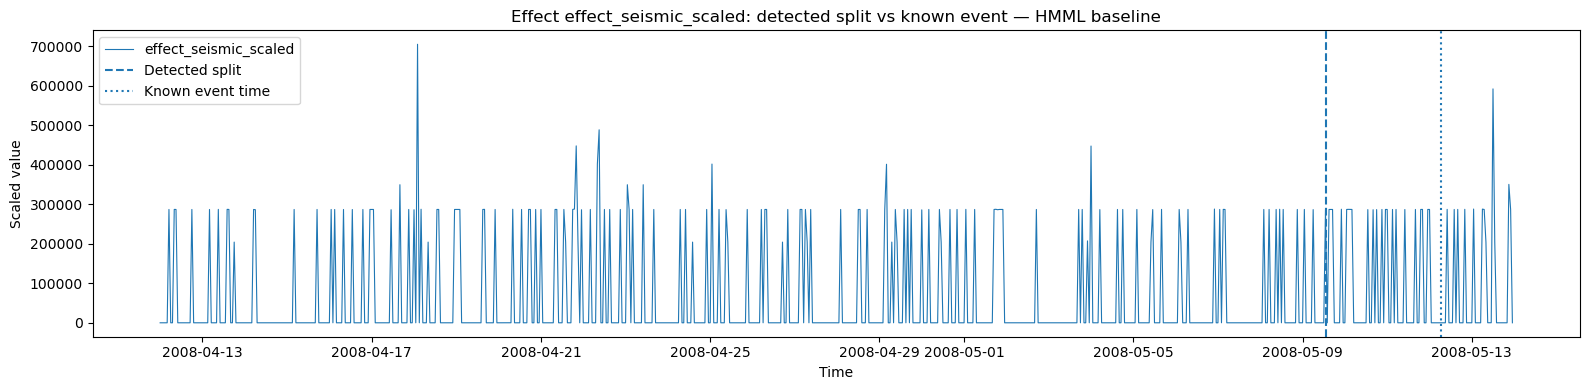

In [18]:
plot_effect_with_split(
    df=X_FULL,
    effect=EFFECT,
    result=result_hmml,
    event_time=ETNA_EVENT_TIME,
    title_suffix="— HMML baseline",
)

## 10. Optional automatic lag selection

This section uses VAR/AIC to select a lag.  
Because the scaled variables can be negative, the distribution is forced to Gaussian.

In [19]:
_, selected_lag = find_parameters(
    X=X_FULL,
    target_series=X_FULL[EFFECT],
    max_lags=MAX_LAGS,
    criterion="aic",
    fallback_lag=1,
    fallback_distribution="gaussian",
)

selected_distribution = "gaussian"

print("Effect:", EFFECT)
print("Selected lag:", selected_lag)
print("Forced distribution:", selected_distribution)

Effect: effect_seismic_scaled
Selected lag: 3
Forced distribution: gaussian


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


## 11. Automatic-lag comparison across three backends

This repeats the three-backend comparison using the selected lag.

In [20]:
auto_run_specs = [
    {"run": "hmml_auto_backend_beta", "backend": "hmml", "refit_method": None},
    {"run": "pcmci_auto_ridge", "backend": "pcmci", "refit_method": "ridge"},
    {"run": "pcmci_auto_adaptive_lasso", "backend": "pcmci", "refit_method": "adaptive_lasso"},
    {"run": "pcmci_plus_auto_ridge", "backend": "pcmci_plus", "refit_method": "ridge"},
    {"run": "pcmci_plus_auto_adaptive_lasso", "backend": "pcmci_plus", "refit_method": "adaptive_lasso"},
]

auto_results = {}
auto_diags = {}

for spec in auto_run_specs:
    run_name = spec["run"]
    backend = spec["backend"]

    try:
        config = make_config(
            backend=backend,
            effect=EFFECT,
            lag=selected_lag,
            distribution=selected_distribution,
            parameter_source=f"{run_name}_VAR_AIC_lag_gaussian_scaled_full_dataset",
            cond_ind_test="parcorr",
            refit_method=spec["refit_method"],
        )

        result = run_cause_trigger(X_FULL, config)
        diag = summarize_result(result, title=f"{run_name} result")

        auto_results[run_name] = result
        auto_diags[run_name] = diag

    except Exception as e:
        print(f"{run_name} auto-lag run failed:", e)

auto_comparison = pd.DataFrame([
    compact_result_row(run_name, EFFECT, result)
    for run_name, result in auto_results.items()
])

display(auto_comparison)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom



hmml_auto_backend_beta result
Backend: hmml
Configured lags: 3
Configured distribution: gaussian
Parameter source: hmml_auto_backend_beta_VAR_AIC_lag_gaussian_scaled_full_dataset
V weighting: backend
Refit method: None
Refit metadata:


{'v_weighting': 'backend', 'source': 'hmml'}

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: ['background_seismic_scaled']
B2: ['CO2_3_scaled']
Autoregressive effect parent in B2: False
Trigger candidates: ['CO2_3_scaled']
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
HMML metadata:


{'requested_distribution': 'gaussian',
 'used_distribution': 'gaussian',
 'used_fallback': False}

...

Split index: 661
Split timestamp: 2008-05-09 13:00:00+00:00
I1 length: 661
I2 length: 107
Effect abs mean difference: 36690.03912551033
B1: []
B2: []
Autoregressive effect parent in B2: False
Trigger candidates: []
Accepted triggers: []
Causes: []
Cause-trigger pairs: []
PCMCI/PCMCI+ metadata:


{'method': 'pcmci_plus',
 'tau_max': 3,
 'pc_alpha': 0.05,
 'alpha_level': 0.05,
 'fdr_method': 'fdr_bh',
 'cond_ind_test': 'parcorr',
 'contemp_collider_rule': 'majority',
 'conflict_resolution': True}

PCMCI+ contemporaneous tau=0 links to effect, stored as diagnostics only:


,graph_link,p_value,val
teleseismic_scaled,o-o,4.141430e-34,0.883871
background_seismic_scaled,o-o,5.523163e-05,0.391904


,run,effect,backend,parameter_source,configured_lags,configured_distribution,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,split_index,split_timestamp,I1_length,I2_length,B1,B2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links
0,hmml_auto_backend_beta,effect_seismic_scaled,hmml,hmml_auto_backend_beta_VAR_AIC_lag_gaussian_scaled_full_dataset,3,gaussian,backend,None,NaN,None,661,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0
1,pcmci_auto_ridge,effect_seismic_scaled,pcmci,pcmci_auto_ridge_VAR_AIC_lag_gaussian_scaled_full_dataset,3,gaussian,refit,ridge,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0
2,pcmci_auto_adaptive_lasso,effect_seismic_scaled,pcmci,pcmci_auto_adaptive_lasso_VAR_AIC_lag_gaussian_scaled_full_dataset,3,gaussian,refit,adaptive_lasso,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0
3,pcmci_plus_auto_ridge,effect_seismic_scaled,pcmci_plus,pcmci_plus_auto_ridge_VAR_AIC_lag_gaussian_scaled_full_dataset,3,gaussian,refit,ridge,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[],[],False,[],[],[],[],2
4,pcmci_plus_auto_adaptive_lasso,effect_seismic_scaled,pcmci_plus,pcmci_plus_auto_adaptive_lasso_VAR_AIC_lag_gaussian_scaled_full_dataset,3,gaussian,refit,adaptive_lasso,0.0,None,661,2008-05-09 13:00:00+00:00,661,107,[],[],False,[],[],[],[],2


## 12. Sensitivity grid across backend and lag

This section tests stability across:

- backend: HMML, PCMCI, PCMCI+
- lag: 1 to `MAX_LAGS`
- distribution: Gaussian

For Etna, we start with `parcorr`.

In [21]:
def run_sensitivity_grid(
    df_model,
    effect,
    run_specs=None,
    lags=(1, 2, 3),
    distributions=("gaussian",),
    min_I1_length=48,
    min_I2_length=48,
    cond_ind_test="parcorr",
):
    if run_specs is None:
        run_specs = [
            {"run": "hmml_backend_beta", "backend": "hmml", "refit_method": None},
            {"run": "pcmci_ridge", "backend": "pcmci", "refit_method": "ridge"},
            {"run": "pcmci_adaptive_lasso", "backend": "pcmci", "refit_method": "adaptive_lasso"},
            {"run": "pcmci_plus_ridge", "backend": "pcmci_plus", "refit_method": "ridge"},
            {"run": "pcmci_plus_adaptive_lasso", "backend": "pcmci_plus", "refit_method": "adaptive_lasso"},
        ]
    rows = []

    for spec in run_specs:
        run_name = spec["run"]
        backend = spec["backend"]
        refit_method = spec["refit_method"]

        for lag in lags:
            for distribution in distributions:
                config = make_config(
                    backend=backend,
                    effect=effect,
                    lag=lag,
                    distribution=distribution,
                    parameter_source=f"{run_name}_sensitivity_grid",
                    cond_ind_test=cond_ind_test,
                    refit_method=refit_method,
                )

                # Explicitly set interval lengths in case the function arguments differ
                config.min_I1_length = min_I1_length
                config.min_I2_length = min_I2_length

                try:
                    result = run_cause_trigger(df_model, config)
                    diagnostics = diagnostics_to_dataframe(result)

                    rows.append({
                        "effect": effect,
                        "backend": backend,
                        "lag": lag,
                        "distribution": distribution,
                        "cond_ind_test": cond_ind_test if backend in {"pcmci", "pcmci_plus"} else None,
                        "run": run_name,
                        "v_weighting": result.get("v_weighting"),
                        "refit_method": result.get("refit_method"),
                        "refit_nonzero_beta_count": (
                            result.get("refit_metadata", {}).get("nonzero_beta_count")
                            if result.get("refit_metadata") else None
                        ),
                        "refit_alpha_used": (
                            result.get("refit_metadata", {}).get("refit_alpha_used")
                            if result.get("refit_metadata") else None
                        ),
                        "split_timestamp": result.get("split_timestamp"),
                        "I1_length": result.get("I1_length"),
                        "I2_length": result.get("I2_length"),
                        "B_1": result.get("B_1"),
                        "B_2": result.get("B_2"),
                        "autoregressive_effect_parent_in_B2": result.get("autoregressive_parent_in_B2"),
                        "trigger_candidates": result.get("T_candidates"),
                        "accepted_triggers": result.get("T"),
                        "causes": result.get("C"),
                        "pairs": result.get("pairs"),
                        "n_contemporaneous_links": len(result.get("contemporaneous_links", {}) or {}),
                        "n_diagnostics": len(diagnostics),
                        "min_p_value": diagnostics["p_value"].min()
                            if "p_value" in diagnostics.columns and len(diagnostics) > 0
                            else None,
                        "max_rss_reduction_ratio": diagnostics["rss_reduction_ratio"].max()
                            if "rss_reduction_ratio" in diagnostics.columns and len(diagnostics) > 0
                            else None,
                    })

                except Exception as e:
                    rows.append({
                        "effect": effect,
                        "backend": backend,
                        "lag": lag,
                        "distribution": distribution,
                        "cond_ind_test": cond_ind_test if backend in {"pcmci", "pcmci_plus"} else None,
                        "run": run_name,
                        "v_weighting": result.get("v_weighting"),
                        "refit_method": result.get("refit_method"),
                        "refit_nonzero_beta_count": (
                            result.get("refit_metadata", {}).get("nonzero_beta_count")
                            if result.get("refit_metadata") else None
                        ),
                        "refit_alpha_used": (
                            result.get("refit_metadata", {}).get("refit_alpha_used")
                            if result.get("refit_metadata") else None
                        ),
                        "error": str(e),
                    })

    return pd.DataFrame(rows)


sensitivity_df = run_sensitivity_grid(
    df_model=X_FULL,
    effect=EFFECT,
    lags=tuple(range(1, MAX_LAGS + 1)),
    distributions=("gaussian",),
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    cond_ind_test="parcorr",
)

display(sensitivity_df)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

,effect,backend,lag,distribution,cond_ind_test,run,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,split_timestamp,I1_length,I2_length,B_1,B_2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,n_diagnostics,min_p_value,max_rss_reduction_ratio
0,effect_seismic_scaled,hmml,1,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,0,None,None
1,effect_seismic_scaled,hmml,2,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,0,None,None
2,effect_seismic_scaled,hmml,3,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,0,None,None
3,effect_seismic_scaled,hmml,4,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,0,None,None
4,effect_seismic_scaled,hmml,5,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,107,[WindSpeed_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,0,None,None
5,effect_seismic_scaled,hmml,6,gaussian,None,hmml_backend_beta,backend,None,NaN,None,2008-05-09 13:00:00+00:00,661,107,[WindSpeed_scaled],[CO2_3_scaled],False,[CO2_3_scaled],[],[],[],0,0,None,None
6,effect_seismic_scaled,pcmci,1,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,107,"[teleseismic_scaled, background_seismic_scaled, effect_seismic_scaled]",[],False,[],[],[],[],0,0,None,None
7,effect_seismic_scaled,pcmci,2,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0,0,None,None
8,effect_seismic_scaled,pcmci,3,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0,0,None,None
9,effect_seismic_scaled,pcmci,4,gaussian,parcorr,pcmci_ridge,refit,ridge,0.0,None,2008-05-09 13:00:00+00:00,661,107,[background_seismic_scaled],[],False,[],[],[],[],0,0,None,None


## 13. Accepted-trigger stability

This table shows only configurations that produced accepted triggers.  

In [22]:
if "accepted_triggers" in sensitivity_df.columns:
    accepted_sensitivity = sensitivity_df[
        sensitivity_df["accepted_triggers"].apply(lambda x: isinstance(x, list) and len(x) > 0)
    ].copy()
else:
    accepted_sensitivity = pd.DataFrame()

print("Sensitivity runs with accepted triggers:")
display(accepted_sensitivity)

if len(accepted_sensitivity) == 0:
    print("No accepted triggers under the tested configurations.")
else:
    print("Accepted trigger configurations found. Check whether they are stable across lag/backend.")

Sensitivity runs with accepted triggers:


,effect,backend,lag,distribution,cond_ind_test,run,v_weighting,refit_method,refit_nonzero_beta_count,refit_alpha_used,split_timestamp,I1_length,I2_length,B_1,B_2,autoregressive_effect_parent_in_B2,trigger_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,n_diagnostics,min_p_value,max_rss_reduction_ratio


No accepted triggers under the tested configurations.


## 14. PCMCI/PCMCI+ conditional-test (Robust-ParCorr) sensitivity

In [24]:
robust_run_specs = [
    {"run": "pcmci_ridge_robust", "backend": "pcmci", "refit_method": "ridge"},
    {"run": "pcmci_adaptive_lasso_robust", "backend": "pcmci", "refit_method": "adaptive_lasso"},
    {"run": "pcmci_plus_ridge_robust", "backend": "pcmci_plus", "refit_method": "ridge"},
    {"run": "pcmci_plus_adaptive_lasso_robust", "backend": "pcmci_plus", "refit_method": "adaptive_lasso"},
]

sensitivity_robust_df = run_sensitivity_grid(
    df_model=X_FULL,
    effect=EFFECT,
    run_specs=robust_run_specs,
    lags=tuple(range(1, MAX_LAGS + 1)),
    distributions=("gaussian",),
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    cond_ind_test="robust_parcorr",
)

In [25]:
if len(all_diag) > 0:
    trigger_stability = (
        all_diag
        .groupby(["trigger", "run", "backend", "refit_method"], dropna=False)
        .agg(
            accepted=("accepted", "max"),
            min_p_value=("p_value", "min"),
            max_rss_reduction_ratio=("rss_reduction_ratio", "max"),
            max_V_std=("V_std", "max") if "V_std" in all_diag.columns else ("accepted", "count"),
        )
        .reset_index()
        .sort_values(["trigger", "accepted", "min_p_value"], ascending=[True, False, True])
    )

    display(trigger_stability)
else:
    print("No diagnostics available for trigger-stability table.")

No diagnostics available for trigger-stability table.
